In [129]:
import pandas as pd

In [130]:
df = pd.read_csv('C:/SAG/Air-Channel/files(Oct21-21)/Airchannel_Data.csv', encoding='latin1')
df1 = pd.read_csv('C:/SAG/Air-Channel/files(Oct21-21)/phonenum_purchased.csv', dtype={'phone_number': int})
df2 = pd.read_csv('C:/SAG/Air-Channel/files(Oct21-21)/phonenum_assigned.csv', dtype={'phone_number': int})
df3 = pd.read_csv('C:/SAG/Air-Channel/files(Oct21-21)/phonenum_renewed.csv', low_memory=False, dtype={'phone_number': int})

In [131]:
print(df.shape)
df.head()

(19065, 4)


,Person - Email,Person - Country,Person - Phone,Person - Converted
0,nowex78424@avashost.com,United States,'+17158542266,NaN
1,hokegal583@bariswc.com,United States,'+13132004256,NaN
2,office@europe-machinerygmbh.de,Germany,'+4915211958439,NaN
3,lbnj.yparg73@puxah.org,Cambodia,'+85511120000,NaN
4,darshan@blackcheriemedia.com,India,'+919623379656,NaN


In [132]:
df = df.rename(columns={
    'Person - Email': 'email',
    'Person - Country': 'country',
    'Person - Phone': 'phone',
    'Person - Converted': 'converted'
})

df['converted'] = df['converted'].fillna('No')

df.head()

,email,country,phone,converted
0,nowex78424@avashost.com,United States,'+17158542266,No
1,hokegal583@bariswc.com,United States,'+13132004256,No
2,office@europe-machinerygmbh.de,Germany,'+4915211958439,No
3,lbnj.yparg73@puxah.org,Cambodia,'+85511120000,No
4,darshan@blackcheriemedia.com,India,'+919623379656,No


In [133]:
df['email'] = df['email'].str.strip().str.lower()
df['country'] = df['country'].str.strip().str.title()
df['converted'] = df['converted'].str.strip().str.lower()
df['phone'] = df['phone'].astype(str).str.replace(r'[^+\d]', '', regex=True)

df.head()

,email,country,phone,converted
0,nowex78424@avashost.com,United States,+17158542266,no
1,hokegal583@bariswc.com,United States,+13132004256,no
2,office@europe-machinerygmbh.de,Germany,+4915211958439,no
3,lbnj.yparg73@puxah.org,Cambodia,+85511120000,no
4,darshan@blackcheriemedia.com,India,+919623379656,no


In [134]:
print(df.isnull().sum())
print("\n")
print(df.isnull().all(axis=1).sum())
print("\n")
print(df.duplicated().sum())

email        11
country      32
phone         0
converted     0
dtype: int64


0


20


In [135]:
df.dropna(how='all',inplace=True)
df.dropna(subset=['email'],inplace=True)
df.drop_duplicates(inplace=True)

print(df.isnull().sum())
print("\n")
print(df.isnull().all(axis=1).sum())
print("\n")
print(df.duplicated().sum())

email         0
country      24
phone         0
converted     0
dtype: int64


0


0


In [136]:
df['converted'].value_counts()

converted
no     18695
yes      346
Name: count, dtype: int64

In [137]:
print(346/(18695+346)*100)

1.81713145317998


In [138]:
converted = df[df['converted'] == 'yes']
not_converted = df[df['converted'] == 'no']

In [139]:
converted.head()

,email,country,phone,converted
9,wagners11@freesourcecodes.com,United States,+19204490429,yes
142,rajveer@wsu.university,India,+919109198978,yes
176,layth@joinkula.io,United Kingdom,+447753258021,yes
197,info@leadsolympia.com,United States,+19179620802,yes
206,lgarcia@chcnetwork.org,United States,+15107170032,yes


In [140]:
not_converted.head()

,email,country,phone,converted
0,nowex78424@avashost.com,United States,+17158542266,no
1,hokegal583@bariswc.com,United States,+13132004256,no
2,office@europe-machinerygmbh.de,Germany,+4915211958439,no
3,lbnj.yparg73@puxah.org,Cambodia,+85511120000,no
4,darshan@blackcheriemedia.com,India,+919623379656,no


In [141]:
print(converted['email'].duplicated().sum())
print(converted['phone'].duplicated().sum())

0
0


In [142]:
df1.head(2)
print(df1.duplicated().sum())
print(df1['phone_number'].duplicated().sum())
print(df1.isnull().sum())
duplicates = df1[df1.duplicated(subset='phone_number', keep=False)]
duplicates = duplicates.sort_values(by = 'phone_number')
duplicates.head(5)


# phone number purchase in pp
pp = df1[['user_id', 'event', 'time', 'phone_number','number_type','phone_number_country']]
pp = pp.sort_values(by='phone_number',ascending = False)
pp.head(2)
pp['Date'] = pd.to_datetime(pp['time'], unit = 's')
pp.head(2)
pp = pp.copy() 

# Convert 'Date' to datetime
pp['Date'] = pd.to_datetime(pp['Date'], errors='coerce')
# Extract 'Month'
pp['Month'] = pp['Date'].dt.to_period('M').astype(str)

pp.head(2)


df2.head(2)
print(df2.duplicated().sum())
print(df2['phone_number'].duplicated().sum())
print(df2.isnull().sum())
duplicates = df2[df2.duplicated(subset='phone_number', keep=False)]
duplicates = duplicates.sort_values(by = 'phone_number')
duplicates.head(5)

# phone number assigned in pa
pa = df2[['user_id', 'event', 'time', 'phone_number','number_type','phone_number_country']]
pa = pa.sort_values(by='phone_number',ascending = False)
pa.head(2)
pa['Date'] = pd.to_datetime(pa['time'], unit ='s')
pa.head(2)
pa = pa.copy() 

# Convert 'Date' to datetime
pa['Date'] = pd.to_datetime(pa['Date'], errors='coerce')
# Extract 'Month'
pa['Month'] = pa['Date'].dt.to_period('M').astype(str)

pa.head(2)


df3.head(2)
df3.columns = df3.columns.str.lower()

# Count duplicate rows
print("Total duplicate rows:", df3.duplicated().sum())

# Count duplicate phone numbers
print("Duplicate phone numbers:", df3['phone number'].duplicated().sum())

# Count all nulls per column
print(df3.isnull().sum())

duplicates = df3[df3.duplicated(subset='phone number', keep=False)]
duplicates = duplicates.sort_values(by = 'phone number')
duplicates.head(5)

def extract_email(row):
    # If $distinct_id_before_identity has a value, use it
    if pd.notnull(row['$distinct_id_before_identity']):
        return row['$distinct_id_before_identity']
    # Otherwise, check distinct_id
    elif pd.notnull(row['distinct_id']):
        # If distinct_id starts with '$device:', it’s not an email
        if str(row['distinct_id']).startswith('$device:'):
            return None
        else:
            return row['distinct_id']
    else:
        return None
    
df3['user_id'] = df3.apply(extract_email, axis=1)
df3 = df3[df3['user_id'].notnull()]


df3 = df3.rename(columns={
    'phone number country':'phone_number_country',
    'phone number':'phone_number'
})
# phone renewed in pr
pr = df3[['user_id', 'event', 'time', 'phone_number','number_type','phone_number_country']]
pr = pr.sort_values(by='phone_number',ascending = False)

# Convert to lowercase
pr['number_type'] = pr['number_type'].str.lower().str.strip()

# Replace only 'tollfree' with 'toll free'
pr['number_type'] = pr['number_type'].replace('tollfree', 'toll free')

pr.head(2)
pr['Date'] = pd.to_datetime(pr['time'], unit = 's')
pr.head(2)
pr = pr.copy() 

# Convert 'Date' to datetime
pr['Date'] = pd.to_datetime(pr['Date'], errors='coerce')
# Extract 'Month'
pr['Month'] = pr['Date'].dt.to_period('M').astype(str)

pr.head(2)


pp_pa_pr = pd.concat([pp, pa, pr], ignore_index=True)
pp_pa_pr.sort_values(by='phone_number', inplace=True)
pp_pa_pr

print(pp_pa_pr.duplicated().sum())
print(pp_pa_pr['phone_number'].duplicated().sum())
pp_pa_pr = pp_pa_pr.drop_duplicates()
print(pp_pa_pr.duplicated().sum())
duplicates = pp_pa_pr[pp_pa_pr.duplicated(subset='phone_number', keep=False)]
duplicates = duplicates.sort_values(by = ['phone_number', 'user_id'])
duplicates.head(20)

0
151
event                               0
time                                0
distinct_id                         0
$insert_id                          0
$lib_version                        0
$mp_api_endpoint                    0
$mp_api_timestamp_ms                0
monthly_price                       0
mp_lib                              0
mp_processing_time_ms               0
number_type                         0
phone_number                        0
phone_number_country                0
user_id                             0
workspace_title                     0
$distinct_id_before_identity     9304
$is_reshuffled                  37930
$preshuffle_distinct_id         37987
dtype: int64
0
1640
event                               0
time                                0
distinct_id                         0
$distinct_id_before_identity     8467
$insert_id                          0
$lib_version                        0
$mp_api_endpoint                    0
$mp_api_timestamp_ms    

,user_id,event,time,phone_number,number_type,phone_number_country,Date,Month
267339,chuhai1314@proton.me,Phone Number Renewed,1759578504,3219410040,local,BE,2025-10-04 11:48:24,2025-10
267338,chuhai1314@proton.me,Phone Number Renewed,1759578194,3219410040,local,BE,2025-10-04 11:43:14,2025-10
267337,chuhai1314@proton.me,Phone Number Renewed,1756924524,3219410040,local,BE,2025-09-03 18:35:24,2025-09
267336,chuhai1314@proton.me,Phone Number Renewed,1759578504,3219410041,local,BE,2025-10-04 11:48:24,2025-10
267335,chuhai1314@proton.me,Phone Number Renewed,1759578194,3219410041,local,BE,2025-10-04 11:43:14,2025-10
267334,chuhai1314@proton.me,Phone Number Renewed,1756924524,3219410041,local,BE,2025-09-03 18:35:24,2025-09
267331,chuhai1314@proton.me,Phone Number Renewed,1759578505,3219410042,local,BE,2025-10-04 11:48:25,2025-10
267332,chuhai1314@proton.me,Phone Number Renewed,1759578194,3219410042,local,BE,2025-10-04 11:43:14,2025-10
267333,chuhai1314@proton.me,Phone Number Renewed,1756924524,3219410042,local,BE,2025-09-03 18:35:24,2025-09
267328,chuhai1314@proton.me,Phone Number Renewed,1759578505,3219410043,local,BE,2025-10-04 11:48:25,2025-10


In [143]:
count_df_all = (
    pp_pa_pr.groupby(['user_id', 'phone_number_country'])
      .agg(phone_count=('phone_number', 'nunique'))
      .reset_index()
)
count_df_all = count_df_all.sort_values(by='phone_count', ascending = False)
count_df_all

,user_id,phone_number_country,phone_count
5632,dfghkiiytdcbjh@gmail.com,GB,2426
12900,lindangfu0801@gmail.com,AU,1799
12320,krispcall@kastcard.com,US,1528
19451,sijie689@gmail.com,AU,1268
4344,chuhai1314@proton.me,CA,1183
...,...,...,...
16,06407lgd@dudscuapcut.store,US,1
3651,bushidoholdingsltd@gmail.com,GB,1
18,086.unique@gmail.com,US,1
19,0bignorris@gmail.com,CH,1


In [144]:
converted = converted.copy()
pp_pa_pr = pp_pa_pr.copy()

converted['email'] = converted['email'].str.strip().str.lower()
pp_pa_pr['user_id'] = pp_pa_pr['user_id'].str.strip().str.lower()

# Merge datasets
con_pp_pa_pr = pd.merge(converted, pp_pa_pr, left_on='email', right_on='user_id', how='left')

# Drop duplicate column (user_id)
con_pp_pa_pr = con_pp_pa_pr.drop(columns=['user_id'])

con_pp_pa_pr = con_pp_pa_pr[['email', 'country', 'phone', 'event', 'Month', 'phone_number', 'phone_number_country']]

print(con_pp_pa_pr.nunique())
con_pp_pa_pr

email                   346
country                  46
phone                   346
event                     3
Month                    13
phone_number            603
phone_number_country     21
dtype: int64


,email,country,phone,event,Month,phone_number,phone_number_country
0,wagners11@freesourcecodes.com,United States,+19204490429,Phone Number Purchased,2025-03,1.805568e+10,US
1,rajveer@wsu.university,India,+919109198978,Phone Number Purchased,2025-01,1.304801e+10,US
2,layth@joinkula.io,United Kingdom,+447753258021,Phone Number Renewed,2024-11,4.477002e+11,GB
3,layth@joinkula.io,United Kingdom,+447753258021,Phone Number Renewed,2024-10,4.477002e+11,GB
4,info@leadsolympia.com,United States,+19179620802,Phone Number Purchased,2025-02,1.929577e+10,US
...,...,...,...,...,...,...,...
1950,hi@betrobot.ai,Turkey,+905322550733,Phone Number Renewed,2025-04,4.474012e+11,GB
1951,headoffice@justtrademarkets.com,India,+917758961093,Phone Number Renewed,2025-03,4.474005e+11,GB
1952,headoffice@justtrademarkets.com,India,+917758961093,Phone Number Renewed,2025-05,4.474005e+11,GB
1953,headoffice@justtrademarkets.com,India,+917758961093,Phone Number Renewed,2025-04,4.474005e+11,GB


In [145]:
count_df_con = (
    con_pp_pa_pr.groupby(['email', 'phone_number_country'])
      .agg(
          country=('country', 'first'),
          phone=('phone', 'first'),
          phone_count=('phone_number', 'nunique')
      )
      .reset_index()
)
count_df_con = count_df_con.sort_values(by='phone_count', ascending = False)
count_df_con

,email,phone_number_country,country,phone,phone_count
232,ujale@satsportnews.com,GB,India,+918349055181,108
224,support@niyousllc.com,US,United States,+12024432132,86
233,ujale@satsportnews.com,US,India,+918349055181,16
231,ujale@satsportnews.com,CA,India,+918349055181,15
24,alberto@albertosardinas.com,CA,United States,+13057259017,13
...,...,...,...,...,...
249,yana@getaltos.com,CA,India,+918449067276,1
251,yash@xebo.ai,CA,India,+919899554578,1
250,yash@xebo.ai,AU,India,+919899554578,1
253,yash@xebo.ai,SG,India,+919899554578,1


In [146]:
# Group by email
count_df_con = (
    count_df_con
    .groupby('email', as_index=False)
    .agg({
        'phone_number_country': lambda x: ', '.join(sorted(set(x.dropna()))),
        #'country': 'first',
        #'phone': 'first',  
        'phone_count': 'sum'  
    })
)
count_df_con = count_df_con.sort_values(by='phone_count', ascending = False)
count_df_con

,email,phone_number_country,phone_count
202,ujale@satsportnews.com,"CA, GB, US",139
195,support@niyousllc.com,US,86
20,alberto@albertosardinas.com,"CA, US",14
87,info@heinrichackermann-bau.de,DE,10
50,evonypena@goflow.co.site,US,9
...,...,...,...
205,varun@tourbureau.us,GB,1
213,wagners11@freesourcecodes.com,US,1
212,vivek.mishra@mindcypress.com,US,1
214,yana@getaltos.com,CA,1


In [147]:
converted[['username', 'domain']] = converted['email'].str.split('@', expand=True)
converted = converted[['email', 'username', 'country', 'domain']]
converted

,email,username,country,domain
9,wagners11@freesourcecodes.com,wagners11,United States,freesourcecodes.com
142,rajveer@wsu.university,rajveer,India,wsu.university
176,layth@joinkula.io,layth,United Kingdom,joinkula.io
197,info@leadsolympia.com,info,United States,leadsolympia.com
206,lgarcia@chcnetwork.org,lgarcia,United States,chcnetwork.org
...,...,...,...,...
18808,saurabh@agentic.it,saurabh,India,agentic.it
18975,edward@ge-ed.co,edward,United States,ge-ed.co
19019,jguevara@smartnutritionfitclub.com,jguevara,United States,smartnutritionfitclub.com
19032,hi@betrobot.ai,hi,Turkey,betrobot.ai


In [148]:
not_converted = not_converted.copy()
not_converted[['username', 'domain']] = not_converted['email'].str.split('@', expand=True)
Not_converted = not_converted[['email', 'username', 'country', 'domain']]
not_converted

,email,country,phone,converted,username,domain
0,nowex78424@avashost.com,United States,+17158542266,no,nowex78424,avashost.com
1,hokegal583@bariswc.com,United States,+13132004256,no,hokegal583,bariswc.com
2,office@europe-machinerygmbh.de,Germany,+4915211958439,no,office,europe-machinerygmbh.de
3,lbnj.yparg73@puxah.org,Cambodia,+85511120000,no,lbnj.yparg73,puxah.org
4,darshan@blackcheriemedia.com,India,+919623379656,no,darshan,blackcheriemedia.com
...,...,...,...,...,...,...
19060,catherine@juliangoldie.com,Philippines,+639333441433,no,catherine,juliangoldie.com
19061,scs@covecreek.us,United States,+18142620916,no,scs,covecreek.us
19062,457emmy@freesourcecodes.com,Canada,+16228536588,no,457emmy,freesourcecodes.com
19063,somemes119@acname.com,United States,+13076218226,no,somemes119,acname.com


In [149]:
converted.to_csv('C:/SAG/Air-Channel/files(Oct21-21)/converted_users.csv', index=False)
not_converted.to_csv('C:/SAG/Air-Channel/files(Oct21-21)/not_converted_users.csv', index=False)
count_df_con.to_csv('C:/SAG/Air-Channel/files(Oct21-21)/converted_phone_number_summary.csv', index=False)

In [150]:
domain_counts = converted['domain'].value_counts().reset_index()
domain_counts.columns = ['domain', 'user_count']
domain_counts


,domain,user_count
0,ondemandint.com,2
1,tutamail.com,2
2,salesforce.com,2
3,firepulseai.com,1
4,futurebytesolutionsinc.com,1
...,...,...
338,hslu.ch,1
339,oxmtalent.com,1
340,outsourceaccelerator.com,1
341,numberscraft.com,1


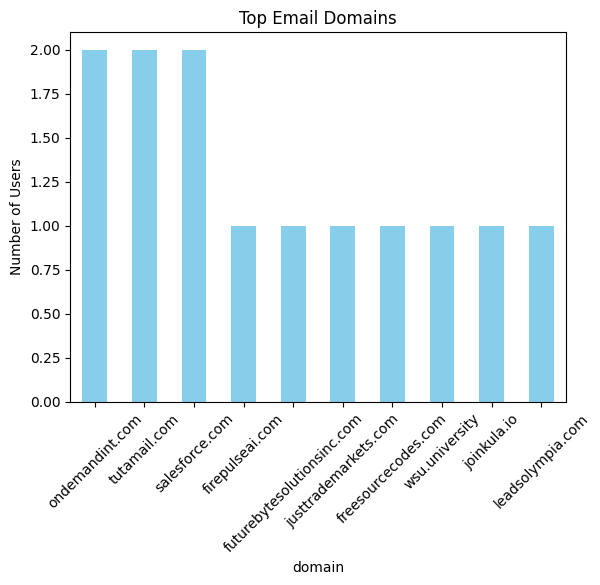

In [151]:
import matplotlib.pyplot as plt

domain_counts.head(10).plot(
    kind='bar', 
    x='domain', 
    y='user_count', 
    legend=False,
    color='skyblue'
)
plt.title('Top Email Domains')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.show()
